read in data
      DATE-OBS     
-------------------
2009-11-02T03:07:41
2009-12-03T02:34:09
2010-03-04T12:21:56
2010-06-27T04:54:25
2010-09-18T06:30:09
2012-04-07T11:34:58
2012-05-11T08:35:19
2012-06-07T08:37:26
2016-04-29T11:02:44
created RV data object


/home/dwich2006/anaconda3/envs/thejoker/lib/python3.10/site-packages/pymc/logprob/abstract.py:236: UserWarning: ValuedVar should not be present in the final graph!
  warnings.warn("ValuedVar should not be present in the final graph!")


rejection sample created
joker samples written out
1 samples
1 sample, needs MCMC


/tmp/ipykernel_3284/134506674.py:85: FutureWarning: The `start` kwarg was renamed to `initvals` and can now do more. Please check the docstring.
  trace = pm.sample(
Initializing NUTS using adapt_full...
/home/dwich2006/anaconda3/envs/thejoker/lib/python3.10/site-packages/pytensor/link/c/cmodule.py:2968: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for 

/home/dwich2006/anaconda3/envs/thejoker/lib/python3.10/site-packages/rich/live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 12 chains for 500 tune and 500 draw iterations (6_000 + 6_000 draws total) took 12 seconds.
There were 2 divergences after tuning. Increase `target_accept` or reparameterize.
/home/dwich2006/anaconda3/envs/thejoker/lib/python3.10/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")


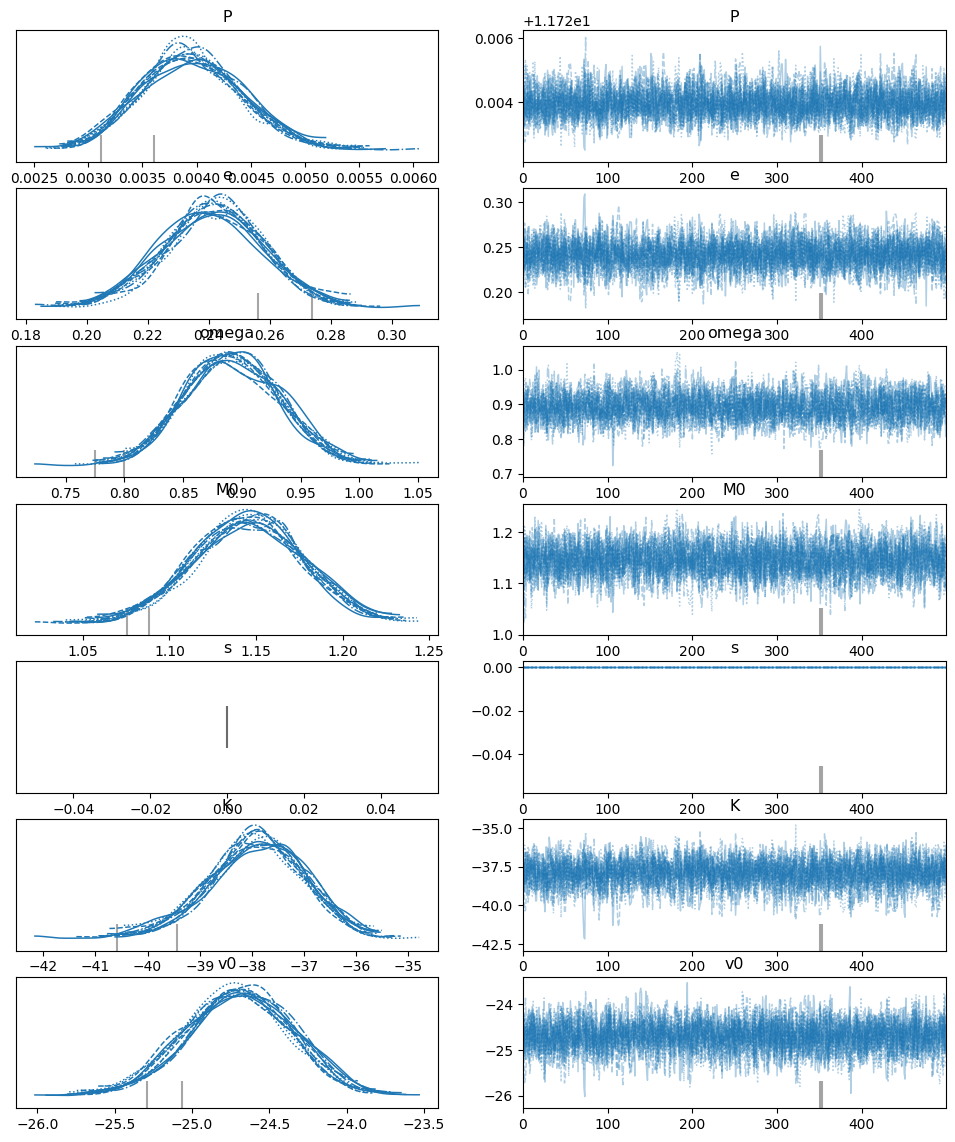

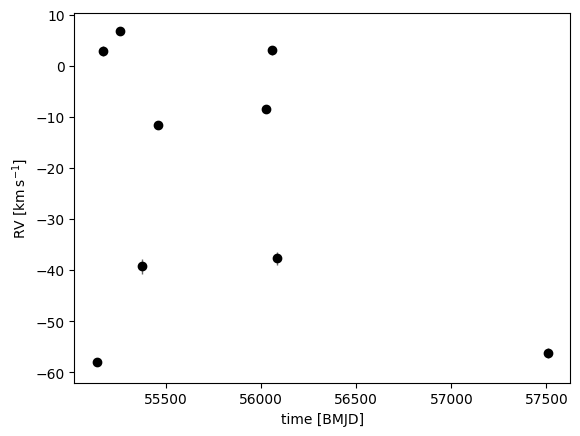

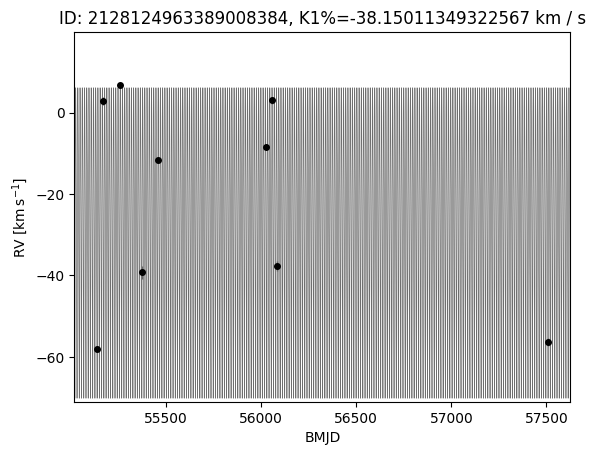

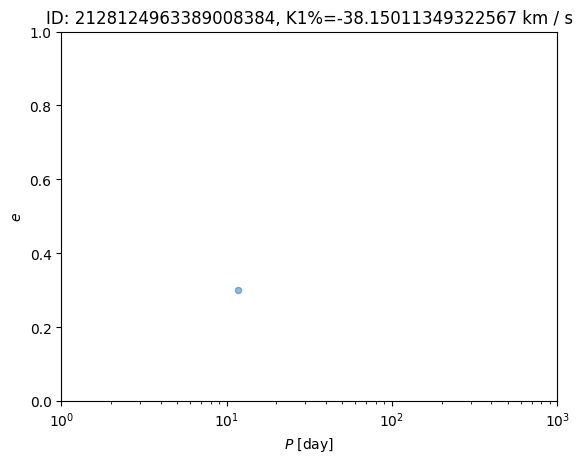

In [1]:
# Ella's Code

import astropy.table as at
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
import h5py
import thejoker as tj
from astropy.table import QTable
from astropy.time import Time
from astropy.visualization.units import quantity_support
import pymc as pm
import arviz as az
import schwimmbad

rnd = np.random.default_rng(seed=42)

data_file = "MWE_RVData.csv"
output_dir = "."  

id_num = 2128124963389008384
mpi = False
num_priors = 1000000
num_chains = 12

dataRV = QTable.read(data_file)
print('read in data')
print(dataRV["DATE-OBS"])

t1 = Time(dataRV["DATE-OBS"], format="isot", scale="tcb")

data = tj.RVData(
    t=t1,
    rv=dataRV['vrad'] * (u.kilometer / u.second),
    rv_err=dataRV['vrad_err'] * 5 * (u.kilometer / u.second)
)

print('created RV data object')

mils = num_priors / 1e6

prior = tj.JokerPrior.default(
    P_min=2 * u.day,
    P_max=1e3 * u.day,
    sigma_K0=30 * u.km / u.s,
    sigma_v=100 * u.km / u.s,
)

prior_samples = prior.sample(size=num_priors, rng=rnd, return_logprobs=True)

prior_file = f"{output_dir}/prior_samples_{mils}M_{id_num}_{num_chains}chains.hdf5"
prior_samples.write(prior_file, overwrite=True)

if mpi:
    with schwimmbad.MultiPool() as pool:
        print("Multiprocessing")
        joker = tj.TheJoker(prior, rng=rnd, pool=pool)
        joker_samples = joker.rejection_sample(
            data,
            prior_samples,
            max_posterior_samples=256,
            return_logprobs=True
        )
else:
    joker = tj.TheJoker(prior, rng=rnd)
    joker_samples = joker.rejection_sample(
        data,
        prior_samples,
        max_posterior_samples=256,
        return_logprobs=True
    )

print('rejection sample created')

rejection_file = f"{output_dir}/rejection_samples_{mils}M_{id_num}_{num_chains}chains.hdf5"
joker_samples.write(rejection_file, overwrite=True)

print('joker samples written out')
print(len(joker_samples), 'samples')

if len(joker_samples) == 1:
    print("1 sample, needs MCMC")

    with prior.model:
        mcmc_init = joker.setup_mcmc(data, joker_samples)
        trace = pm.sample(
            tune=500,
            draws=500,
            start=mcmc_init,
            chains=num_chains,
            init='adapt_full'
        )

    mcmc_samples = tj.JokerSamples.from_inference_data(prior, trace, data)

    az.plot_trace(trace, var_names=prior.par_names)
    plt.show()

    mcmc_samples.write(f"{output_dir}/mcmc_samples.hdf5", overwrite=True)

data.plot()
plt.show()

K = joker_samples['K']
K1st = np.percentile(K, 1)

plt.figure()
tj.plot_rv_curves(joker_samples, data=data)
plt.title(f"ID: {id_num}, K1%={K1st}")
plt.show()

plt.figure()
with quantity_support():
    plt.scatter(joker_samples["P"], joker_samples["e"], s=20, alpha=0.5)

plt.xscale("log")
plt.xlim(1, 1e3)
plt.ylim(0, 1)
plt.xlabel("$P$ [day]")
plt.ylabel("$e$")
plt.title(f"ID: {id_num}, K1%={K1st}")
plt.show()

plt.close('all')

In [1]:
print(K)

NameError: name 'K' is not defined